In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

## Домашняя работа

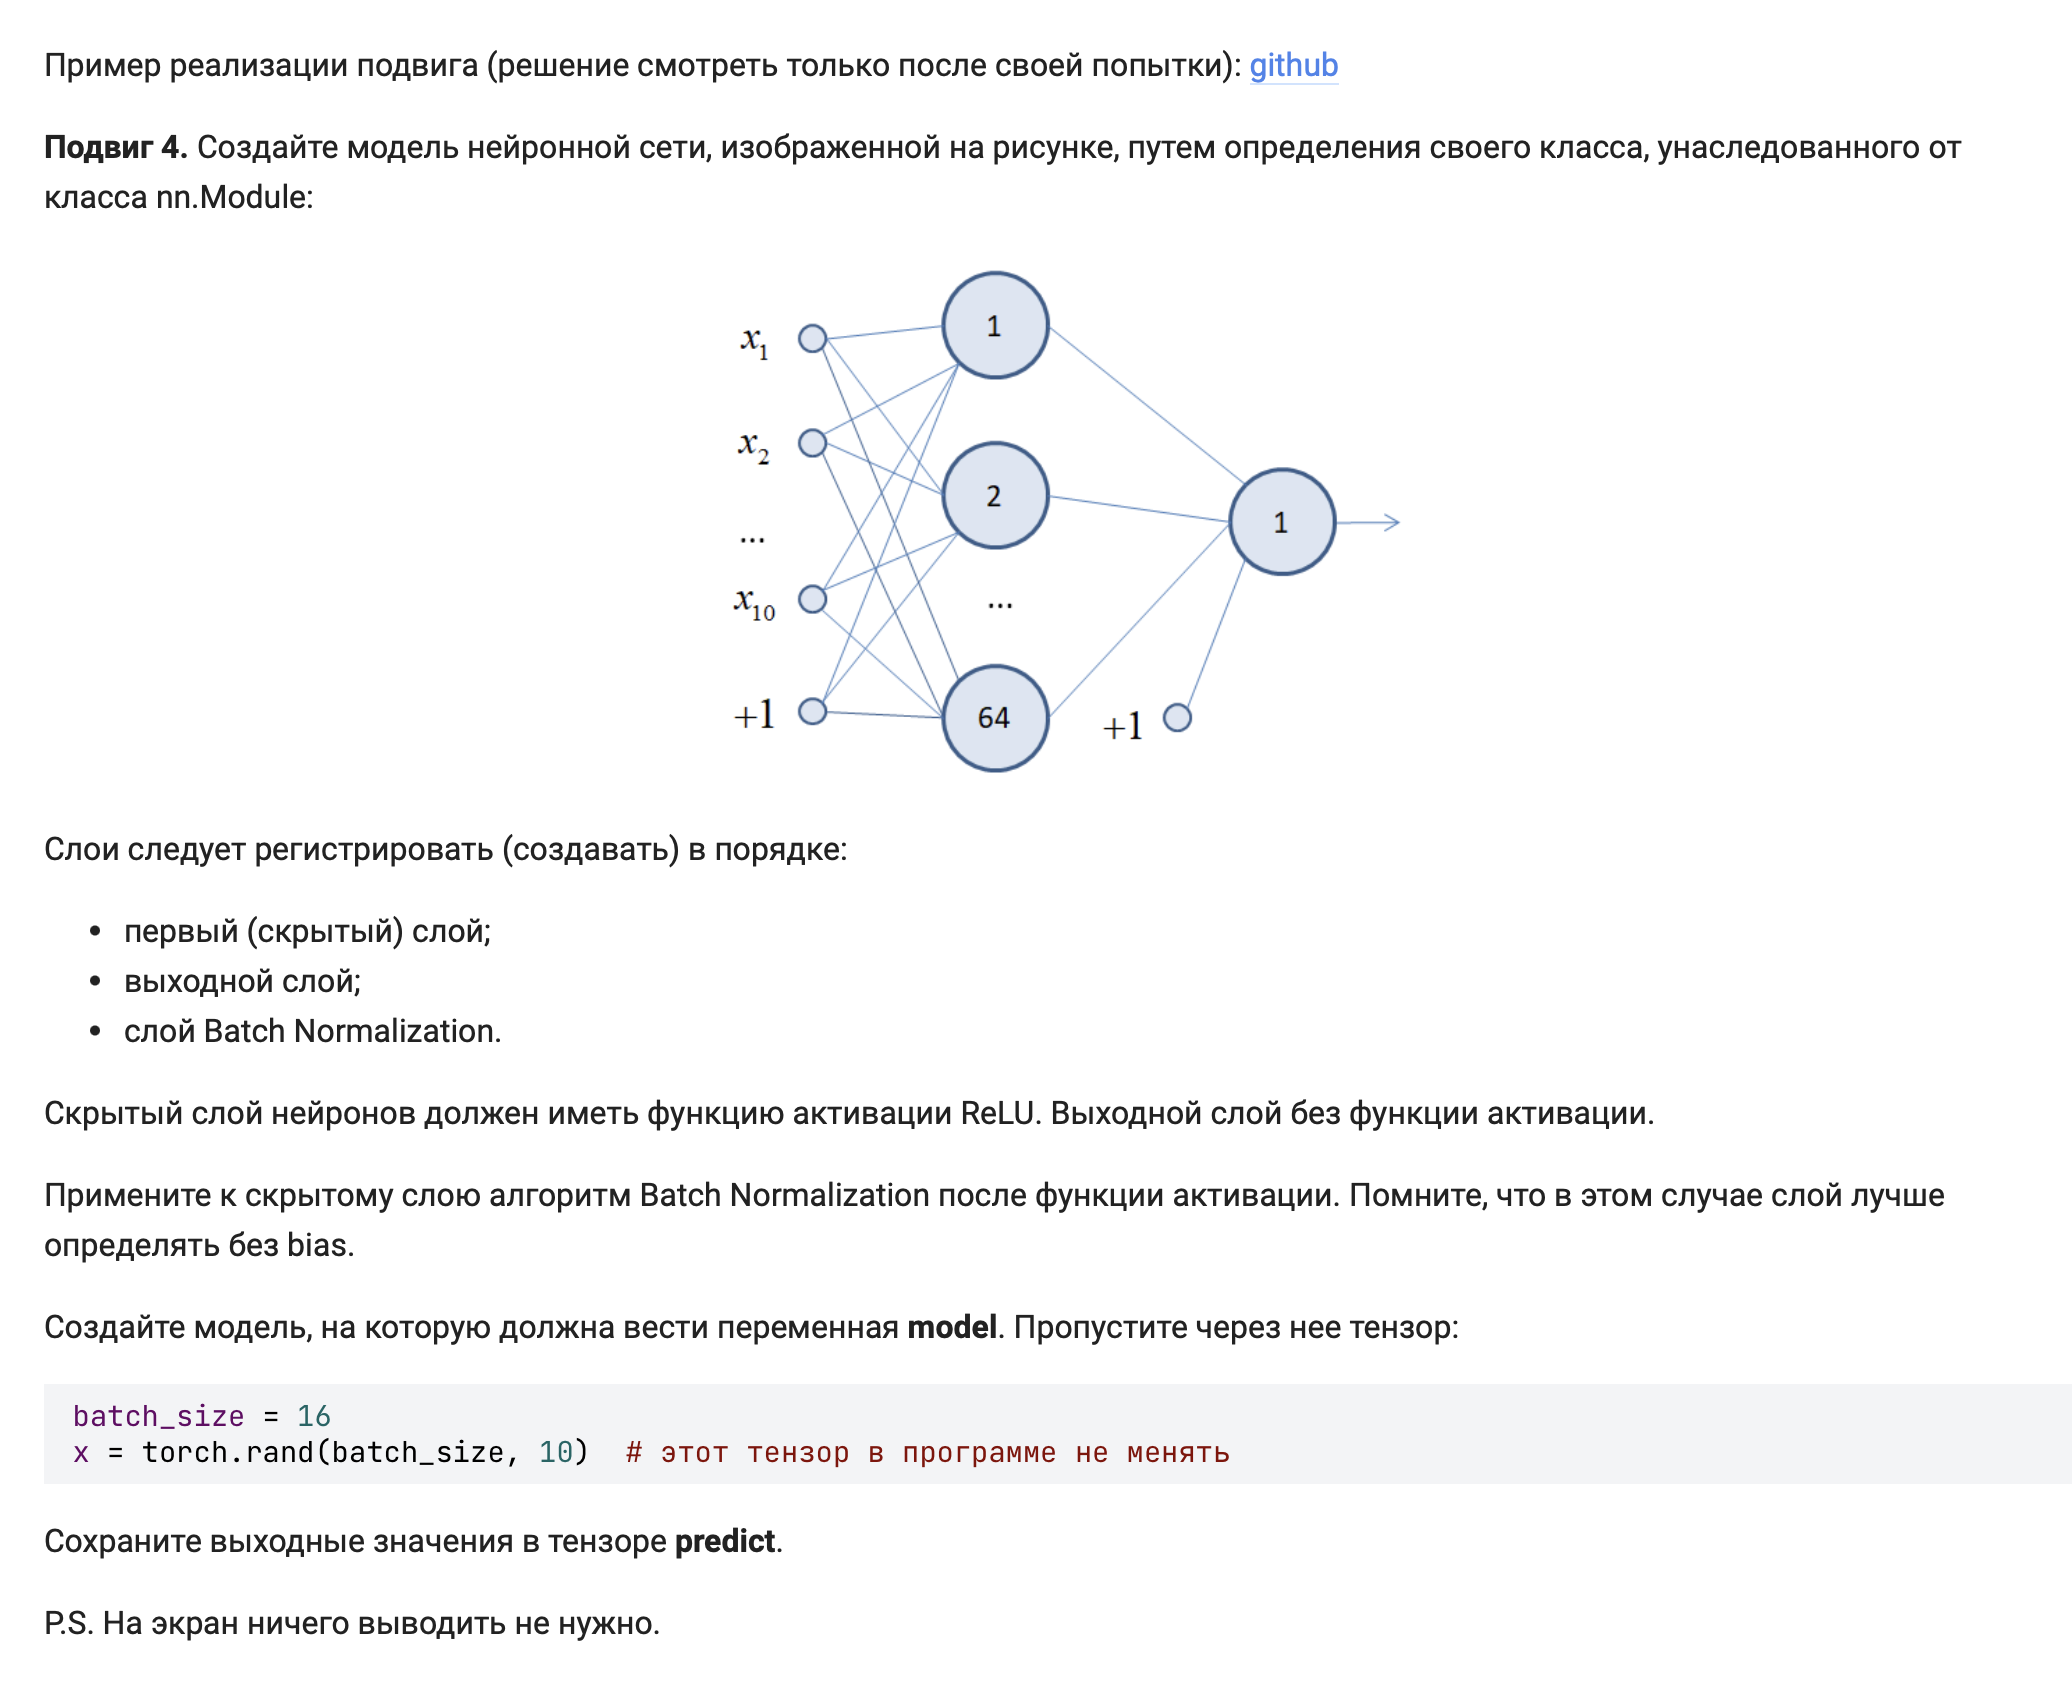

In [8]:
# здесь объявляйте класс модели (важно именно здесь)
class Model(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.l1 = nn.Linear(inp, hid, bias=False)
        self.l2 = nn.Linear(hid, out)
        self.bn = nn.BatchNorm1d(hid)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.bn(x)
        x = self.l2(x)
        return x

model = Model(10, 64, 1) # здесь создавайте объект модели

batch_size = 16
x = torch.rand(batch_size, 10)  # этот тензор в программе не менять

# здесь продолжайте программу
predict = model(x)

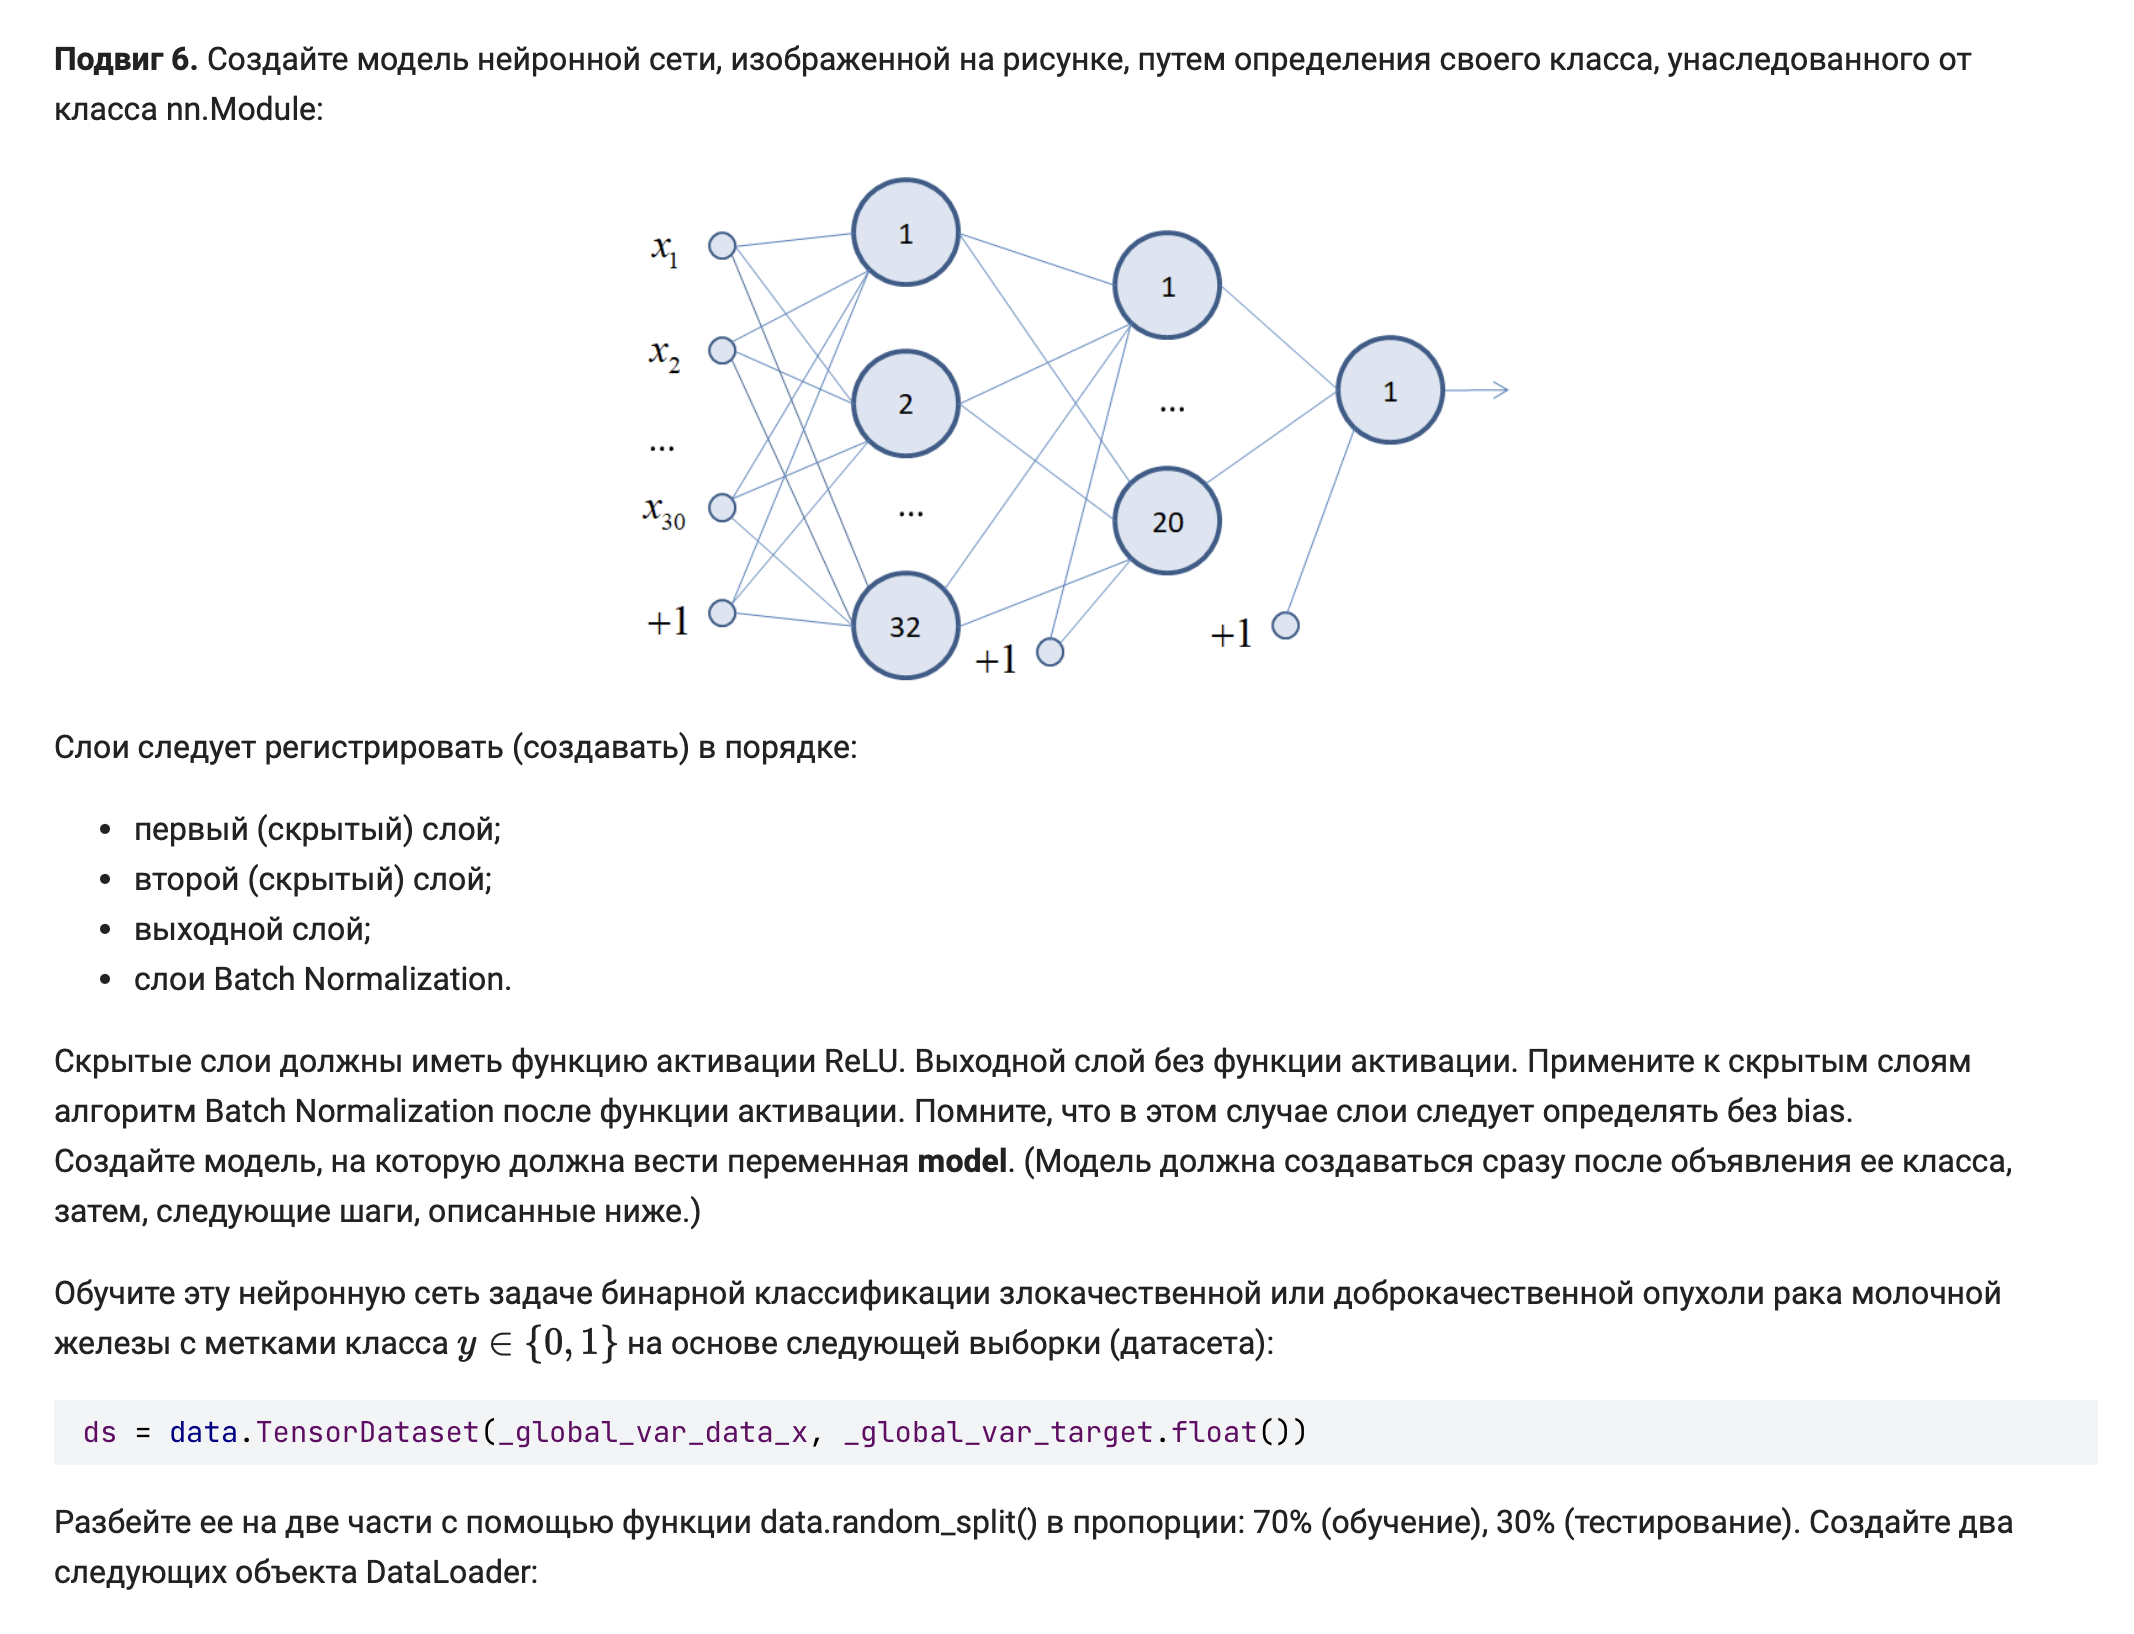
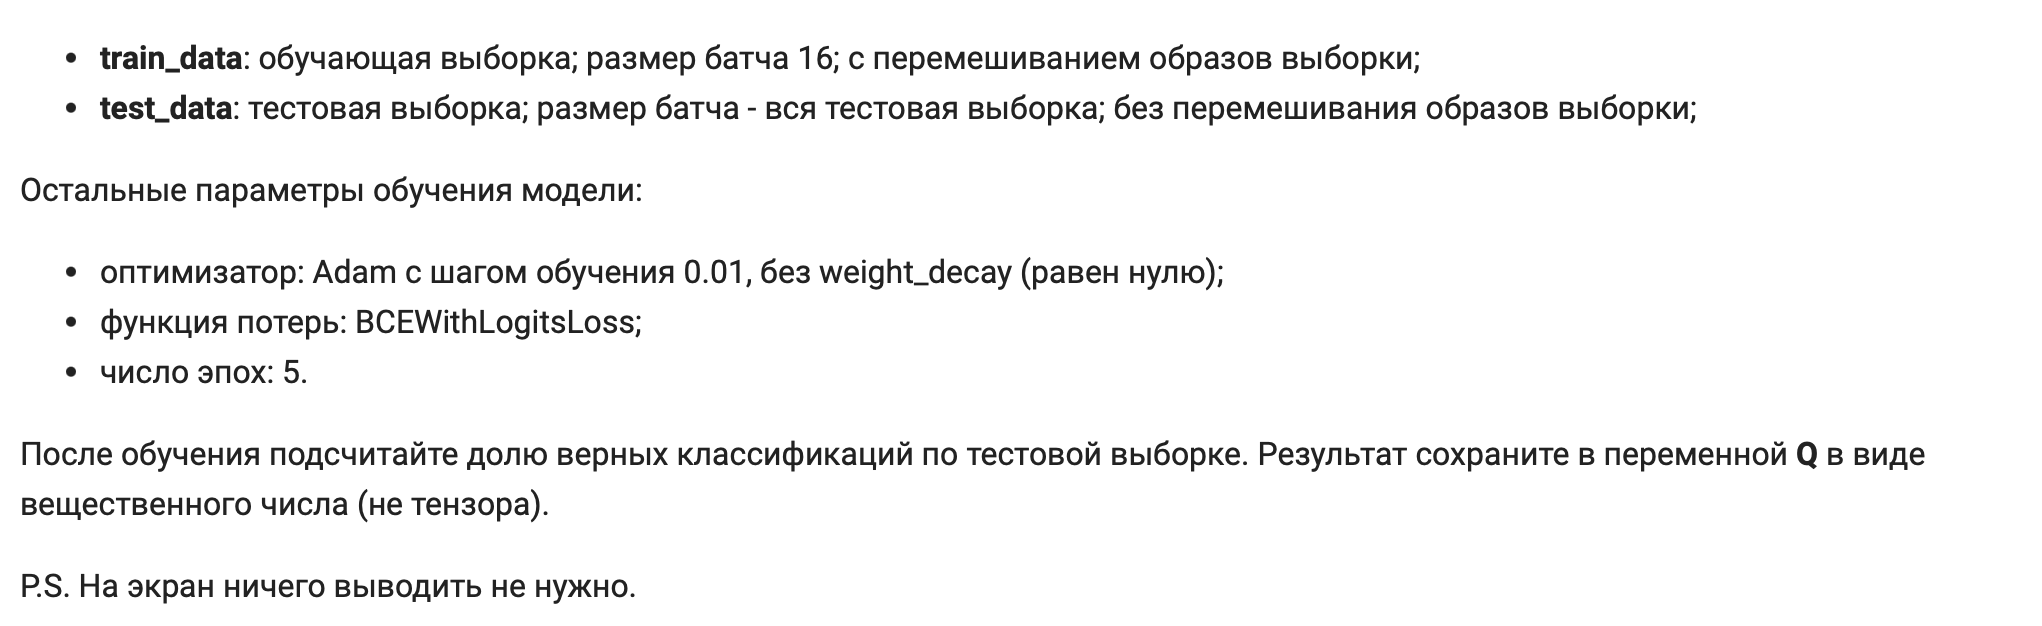

In [17]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

_global_var_data_x = torch.tensor(dataset.data, dtype=torch.float32)
_global_var_target = torch.tensor(dataset.target, dtype=torch.int64)

In [28]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(30, 32, bias=False)
        self.l2 = nn.Linear(32, 20, bias=False)
        self.l3 = nn.Linear(20, 1)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(20)

    def forward(self, x):
        x = self.l1(x).relu()
        x = self.bn1(x)
        x = self.l2(x).relu()
        x = self.bn2(x)
        x = self.l3(x)

        return x
    
model = Model()

ds = data.TensorDataset(_global_var_data_x, _global_var_target.float())
d_train, d_test = data.random_split(ds, [0.7, 0.3])
train_data = data.DataLoader(d_train, batch_size=16, shuffle=True)
test_data = data.DataLoader(d_test, batch_size=len(d_test), shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0)
loss_func = nn.BCEWithLogitsLoss()

model.train()
for i in range(5):
    for x_train, y_train in train_data:
        pred = model(x_train)
        loss = loss_func(pred.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    for x_test, y_test in test_data:
        pred = model(x_test)
        #pred = torch.where(pred >= 0.5, torch.FloatTensor([1]), torch.FloatTensor([0]))
        #Q = (pred == y_test).float().mean().item()
        Q = loss_func(pred.squeeze(), y_test)
Q

tensor(0.5914)